In [72]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

# 'get_human_dataset()' 함수가 정의되지 않아 NameError가 발생했습니다.
# 이 함수는 데이터를 로드하거나 생성하는 역할을 해야 합니다.
# 임시로 더미 데이터를 생성하여 코드를 실행할 수 있도록 수정했습니다.
# 실제 데이터셋을 사용하려면 아래 더미 데이터 생성 코드를 적절히 대체해야 합니다.
import numpy as np
from sklearn.model_selection import train_test_split
# Dummy data generation (replace with your actual data loading)
X, y = np.random.rand(100, 10), np.random.randint(0, 2, 100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


#GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time=time.time()

gb_clf=GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train,y_train)
gb_pred=gb_clf.predict(X_test)
gb_accuracy=accuracy_score(y_test,gb_pred)

print('GBM 정확도: {0: 4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f}초".format(time.time()-start_time))

GBM 정확도:  0.600000
GBM 수행 시간: 0.3초


In [73]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 500],
    'learning_rate': [0.05, 0.1]
}
grid_cv=GridSearchCV(gb_clf,param_grid=params,cv=2,verbose=1,n_jobs=-1)
grid_cv.fit(X_train,y_train)
print('최적 하이퍼 파라미터:\n',grid_cv.best_params_)
print('최고 예측 정확도: {0: 4f}'.format(grid_cv.best_score_))

Fitting 2 folds for each of 4 candidates, totalling 8 fits
최적 하이퍼 파라미터:
 {'learning_rate': 0.05, 'n_estimators': 100}
최고 예측 정확도:  0.557143


In [74]:
import xgboost as xgb
from xgboost import XGBClassifier

In [75]:
import xgboost

print(xgboost.__version__)

3.4.1


In [76]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

cancer_df = pd.DataFrame(data=X_features,columns=dataset.feature_names)
cancer_df['target']=y_label
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [77]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [78]:
# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label,
                                                    test_size=0.2, random_state=156)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [79]:
dtrain = xgb.DMatrix(data=X_train, label=y_train)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [80]:
params = {'max_depth': 3,
          'eta':0.1,
          'objective': 'binary:logistic',
          'eval_metric':'logloss', # 'logoss'를 'logloss'로 수정
          'early_stoppings': 100
          }
num_rounds = 400

In [81]:
# train 데이터 세트는 'train', evaluation(test) 데이터 세트는 'eval'로 명기합니다.
wlist = [(dtrain, 'train'), (dtest, 'eval')]
# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model=xgb.train(params=params, dtrain=dtrain, num_boost_round=num_rounds,\
                    early_stopping_rounds=100, evals=wlist)

[0]	train-logloss:0.58601	eval-logloss:0.56683
[1]	train-logloss:0.52088	eval-logloss:0.50922
[2]	train-logloss:0.46438	eval-logloss:0.45864
[3]	train-logloss:0.41700	eval-logloss:0.41838
[4]	train-logloss:0.37670	eval-logloss:0.38437
[5]	train-logloss:0.34083	eval-logloss:0.35195
[6]	train-logloss:0.31031	eval-logloss:0.32652
[7]	train-logloss:0.28290	eval-logloss:0.30091
[8]	train-logloss:0.25937	eval-logloss:0.28150
[9]	train-logloss:0.23836	eval-logloss:0.26302
[10]	train-logloss:0.21976	eval-logloss:0.24877
[11]	train-logloss:0.20277	eval-logloss:0.23124
[12]	train-logloss:0.18802	eval-logloss:0.21933
[13]	train-logloss:0.17427	eval-logloss:0.20505
[14]	train-logloss:0.16184	eval-logloss:0.19400
[15]	train-logloss:0.15019	eval-logloss:0.18174
[16]	train-logloss:0.14014	eval-logloss:0.17203
[17]	train-logloss:0.13052	eval-logloss:0.16280
[18]	train-logloss:0.12186	eval-logloss:0.15588
[19]	train-logloss:0.11416	eval-logloss:0.14971
[20]	train-logloss:0.10775	eval-logloss:0.14418
[2

In [82]:
pred_probs=xgb_model.predict(dtest)
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정해 리스트 객체인 preds에 저장
preds = [1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:',preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.875 0.002 0.903 0.141 0.989 1.    1.    0.999 0.996 0.   ]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

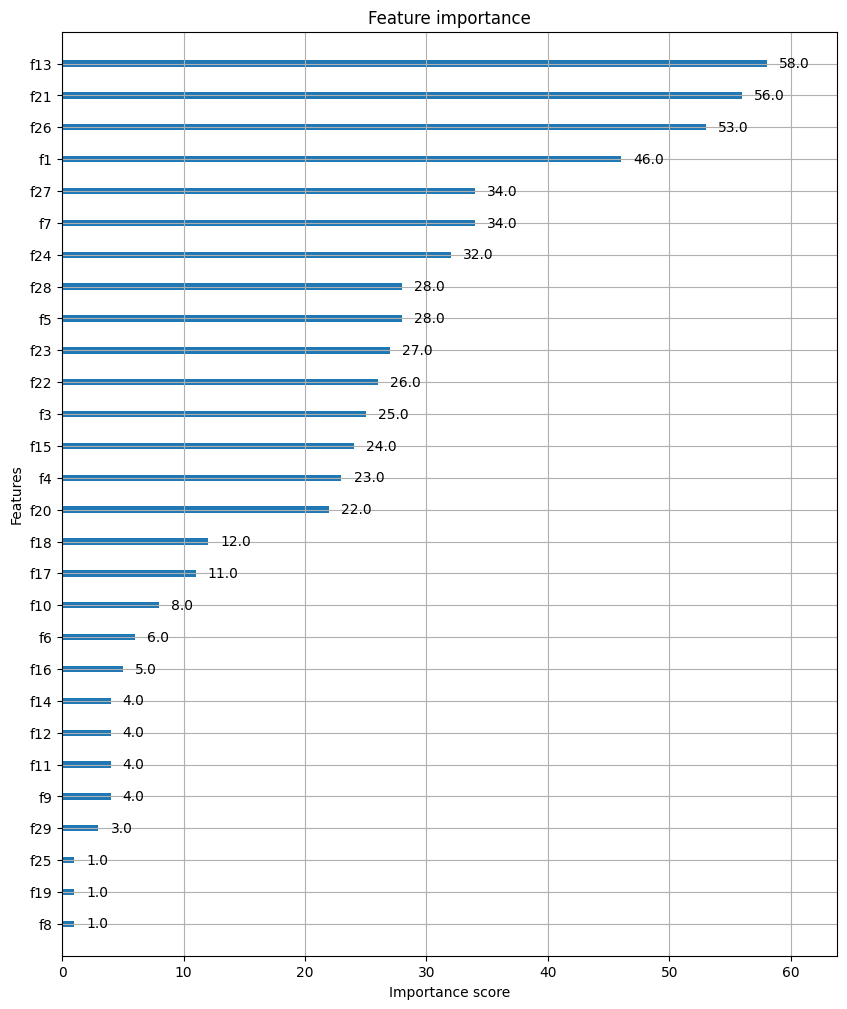

In [83]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax=plt.subplots(figsize=(10,12))
plot_importance(xgb_model,ax=ax)

In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

def get_clf_eval(y_test, pred=None, pred_proba=None):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}')


# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier
xgb_wrapper=XGBClassifier(n_estimators=400,learning_rate=0.1,max_depth=3)
xgb_wrapper.fit(X_train,y_train)
w_preds=xgb_wrapper.predict(X_test)
w_pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test, w_preds, w_pred_proba)

정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870, F1: 0.9806, ROC AUC: 0.9954


In [85]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3,
                            early_stopping_rounds=100, eval_metric='logloss')
evals = [(X_test, y_test)]

xgb_wrapper.fit(X_train, y_train, eval_set=evals, verbose=True)
ws100_preds = xgb_wrapper.predict(X_test)
ws100_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.56683
[1]	validation_0-logloss:0.50922
[2]	validation_0-logloss:0.45864
[3]	validation_0-logloss:0.41838
[4]	validation_0-logloss:0.38437
[5]	validation_0-logloss:0.35195
[6]	validation_0-logloss:0.32652
[7]	validation_0-logloss:0.30091
[8]	validation_0-logloss:0.28150
[9]	validation_0-logloss:0.26302
[10]	validation_0-logloss:0.24877
[11]	validation_0-logloss:0.23124
[12]	validation_0-logloss:0.21933
[13]	validation_0-logloss:0.20505
[14]	validation_0-logloss:0.19400
[15]	validation_0-logloss:0.18174
[16]	validation_0-logloss:0.17203
[17]	validation_0-logloss:0.16280
[18]	validation_0-logloss:0.15588
[19]	validation_0-logloss:0.14971
[20]	validation_0-logloss:0.14418
[21]	validation_0-logloss:0.13650
[22]	validation_0-logloss:0.13049
[23]	validation_0-logloss:0.12617
[24]	validation_0-logloss:0.12168
[25]	validation_0-logloss:0.11868
[26]	validation_0-logloss:0.11532
[27]	validation_0-logloss:0.11300
[28]	validation_0-logloss:0.11006
[29]	validation_0-loglos

In [86]:
get_clf_eval(y_test, ws100_preds, ws100_pred_proba)

정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870, F1: 0.9744, ROC AUC: 0.9961


In [87]:
#early_stopping_rounds를 10으로 설정하고 재학습.
# XGBClassifier 생성자에 early_stopping_rounds와 eval_metric을 전달
xgb_wrapper_10 = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3,
                               early_stopping_rounds=10, eval_metric='logloss')

xgb_wrapper_10.fit(X_train, y_train, eval_set=evals, verbose=True)

ws10_preds = xgb_wrapper_10.predict(X_test)
ws10_pred_proba = xgb_wrapper_10.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.56683
[1]	validation_0-logloss:0.50922
[2]	validation_0-logloss:0.45864
[3]	validation_0-logloss:0.41838
[4]	validation_0-logloss:0.38437
[5]	validation_0-logloss:0.35195
[6]	validation_0-logloss:0.32652
[7]	validation_0-logloss:0.30091
[8]	validation_0-logloss:0.28150
[9]	validation_0-logloss:0.26302
[10]	validation_0-logloss:0.24877
[11]	validation_0-logloss:0.23124
[12]	validation_0-logloss:0.21933
[13]	validation_0-logloss:0.20505
[14]	validation_0-logloss:0.19400
[15]	validation_0-logloss:0.18174
[16]	validation_0-logloss:0.17203
[17]	validation_0-logloss:0.16280
[18]	validation_0-logloss:0.15588
[19]	validation_0-logloss:0.14971
[20]	validation_0-logloss:0.14418
[21]	validation_0-logloss:0.13650
[22]	validation_0-logloss:0.13049
[23]	validation_0-logloss:0.12617
[24]	validation_0-logloss:0.12168
[25]	validation_0-logloss:0.11868
[26]	validation_0-logloss:0.11532
[27]	validation_0-logloss:0.11300
[28]	validation_0-logloss:0.11006
[29]	validation_0-loglos

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

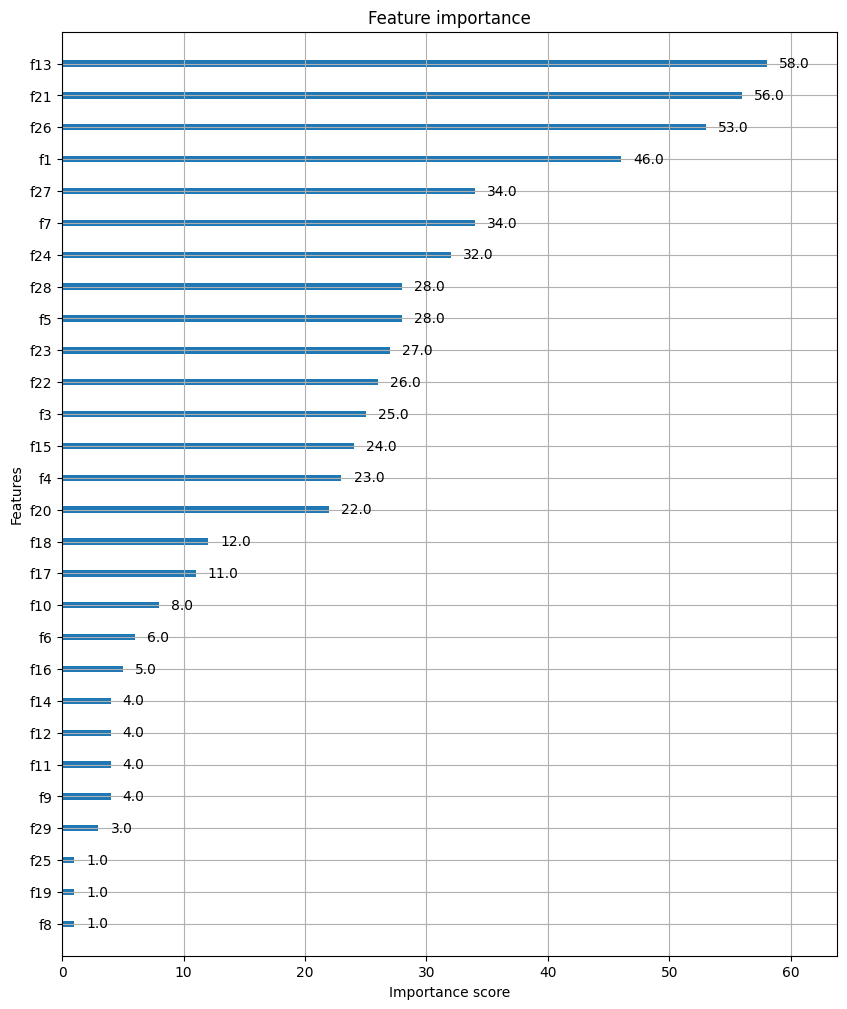

In [88]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax=plt.subplots(figsize=(10,12))
plot_importance(xgb_wrapper,ax=ax)

In [89]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정.
lgbm_wrapper = LGBMClassifier(n_estimators=400, verbose=-1)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능.
evals = [(X_test, y_test)]
lgbm_wrapper.fit(X_train, y_train, eval_metric="logloss", eval_set=evals,
                 callbacks=[early_stopping(stopping_rounds=100),  # = early_stopping_rounds=100
                            log_evaluation(period=1)])            # = verbose=True
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[1]	valid_0's binary_logloss: 0.565079
Training until validation scores don't improve for 100 rounds
[2]	valid_0's binary_logloss: 0.507451
[3]	valid_0's binary_logloss: 0.458489
[4]	valid_0's binary_logloss: 0.417481
[5]	valid_0's binary_logloss: 0.385507
[6]	valid_0's binary_logloss: 0.355773
[7]	valid_0's binary_logloss: 0.329587
[8]	valid_0's binary_logloss: 0.308478
[9]	valid_0's binary_logloss: 0.285395
[10]	valid_0's binary_logloss: 0.267055
[11]	valid_0's binary_logloss: 0.252013
[12]	valid_0's binary_logloss: 0.237018
[13]	valid_0's binary_logloss: 0.224756
[14]	valid_0's binary_logloss: 0.213383
[15]	valid_0's binary_logloss: 0.203058
[16]	valid_0's binary_logloss: 0.194015
[17]	valid_0's binary_logloss: 0.186412
[18]	valid_0's binary_logloss: 0.179108
[19]	valid_0's binary_logloss: 0.174004
[20]	valid_0's binary_logloss: 0.167155
[21]	valid_0's binary_logloss: 0.162494
[22]	valid_0's binary_logloss: 0.156886
[23]	valid_0's binary_logloss: 0.152855
[24]	valid_0's binary_loglo

In [90]:
get_clf_eval(y_test,preds,pred_proba)

정확도: 0.9561, 정밀도: 0.9500, 재현율: 0.9870, F1: 0.9682, ROC AUC: 0.9905


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

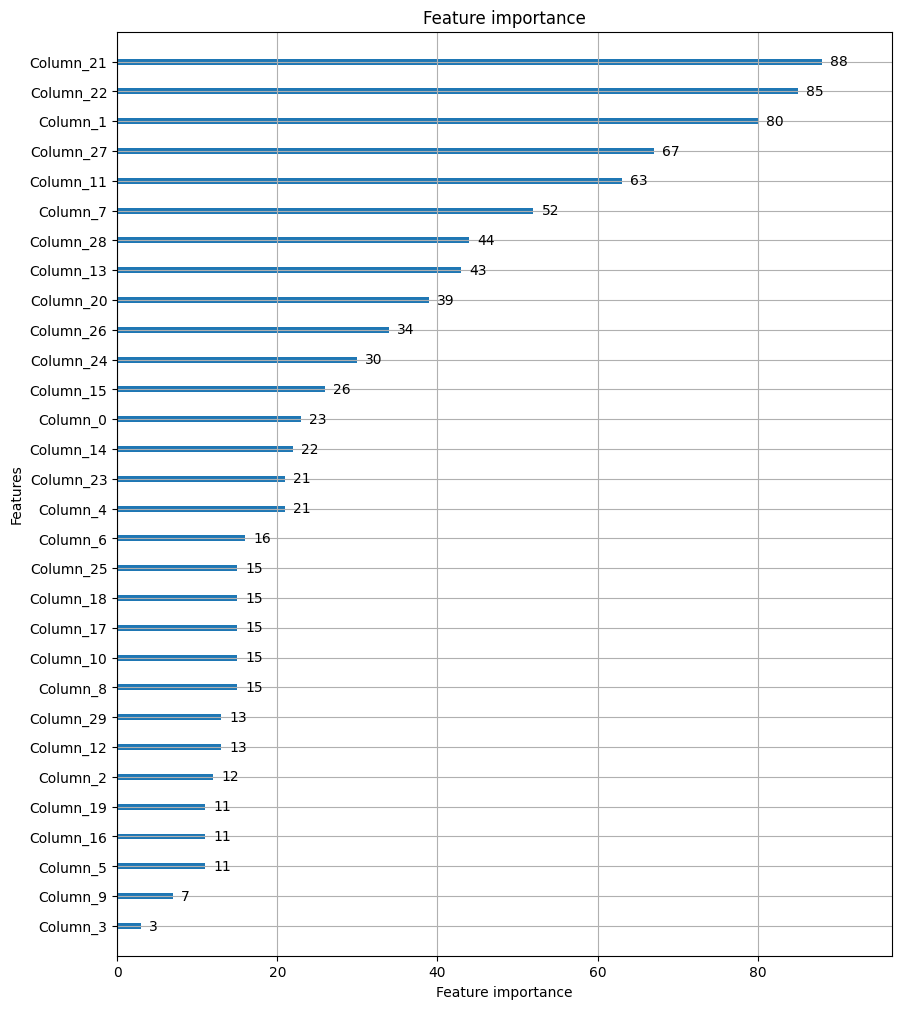

In [91]:
#plot_importance()를 이용해 피처 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax=plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper,ax=ax)

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

cust_df=pd.read_csv("./train_santander.csv", encoding='latin-1')
print('dataset shape:',cust_df.shape)
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [93]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [94]:
print(cust_df['TARGET'].value_counts())
unsatisfied_cnt=cust_df[cust_df['TARGET']==1].TARGET.count()
total_cnt=cust_df.TARGET.count()
print('unsatisfied 비율은 {0:2f}'.format((unsatisfied_cnt / total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.039569


In [95]:
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [109]:
cust_df['var3'].replace(-999999, 2, inplace=True)

# 'ID' 컬럼이 존재할 경우에만 drop합니다.
if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

# TARGET 컬럼에 NaN 값이 있는 행을 제거합니다.
cust_df.dropna(subset=['TARGET'], inplace=True)

#피처 세트와 레이블 세트 분리, 레이블 칼럼은 DataFrame의 맨 마지막에 위치해 칼럼 위치 -1로 분리
X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]
print('피처 데이터 shape:{0}'.format(X_features.shape))

피처 데이터 shape:(76020, 369)


In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels,
                                                    test_size=0.2, random_state=0)
train_cnt=y_train.count()
test_cnt=y_test.count()
print('학습 세트 Shape:{0}, 테스트 세트 Shape: {1}'.format(X_train.shape, X_test.shape))

print(' 학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt*100)
print('\n 테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/test_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape: (15204, 369)
 학습 세트 레이블 값 분포 비율
TARGET
0    96.096422
1     3.903578
Name: count, dtype: float64

 테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


In [107]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

#n_estimators는 500으로, random state는 예제 수행 시마다 동일 예측 결과를 위해 결정
# 성능 평가 지표를 auc로, 조기 중단 파라미터는 100으로 설정하고 학습 수행.
xgb_clf=XGBClassifier(n_estimators=500, random_state=156,
                    early_stopping_rounds=100, eval_metric='auc')

xgb_clf.fit(X_train,y_train,eval_set=[(X_train,y_train),(X_test,y_test)])
xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1],average='macro')
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84308	validation_1-auc:0.82535
[1]	validation_0-auc:0.85122	validation_1-auc:0.83157
[2]	validation_0-auc:0.85485	validation_1-auc:0.83295
[3]	validation_0-auc:0.86099	validation_1-auc:0.83298
[4]	validation_0-auc:0.86410	validation_1-auc:0.83540
[5]	validation_0-auc:0.86662	validation_1-auc:0.83695
[6]	validation_0-auc:0.86891	validation_1-auc:0.83732
[7]	validation_0-auc:0.87094	validation_1-auc:0.83821
[8]	validation_0-auc:0.87273	validation_1-auc:0.83886
[9]	validation_0-auc:0.87414	validation_1-auc:0.83772
[10]	validation_0-auc:0.87597	validation_1-auc:0.83753
[11]	validation_0-auc:0.87782	validation_1-auc:0.83744
[12]	validation_0-auc:0.88029	validation_1-auc:0.83712
[13]	validation_0-auc:0.88081	validation_1-auc:0.83698
[14]	validation_0-auc:0.88142	validation_1-auc:0.83668
[15]	validation_0-auc:0.88235	validation_1-auc:0.83703
[16]	validation_0-auc:0.88434	validation_1-auc:0.83688
[17]	validation_0-auc:0.88454	validation_1-auc:0.83707
[18]	validation_0-au

In [100]:
from sklearn.model_selection import GridSearchCV

# 하이퍼 파라미터 테스트의 수행 속도를 향상시키기 위해 n_estimators를 100으로 감소
# early_stopping_rounds와 eval_metric은 생성자에 설정
xgb_clf = XGBClassifier(n_estimators=100, early_stopping_rounds=30, eval_metric='auc')

params = {'max_depth':[5, 7], 'min_child_weight':[1, 3], 'colsample_bytree':[0.5, 0.75]}

# cv는 3으로 지정
gridcv = GridSearchCV(xgb_clf, param_grid=params, cv=3)
gridcv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

print('GridSearchCV 최적 파라미터:', gridcv.best_params_)

xgb_roc_score = roc_auc_score(y_test, gridcv.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.82233	validation_1-auc:0.81787
[1]	validation_0-auc:0.83000	validation_1-auc:0.82241
[2]	validation_0-auc:0.83968	validation_1-auc:0.82903
[3]	validation_0-auc:0.84445	validation_1-auc:0.83289
[4]	validation_0-auc:0.84541	validation_1-auc:0.83324
[5]	validation_0-auc:0.84845	validation_1-auc:0.83541
[6]	validation_0-auc:0.84974	validation_1-auc:0.83419
[7]	validation_0-auc:0.85181	validation_1-auc:0.83647
[8]	validation_0-auc:0.85345	validation_1-auc:0.83682
[9]	validation_0-auc:0.85616	validation_1-auc:0.83768
[10]	validation_0-auc:0.85665	validation_1-auc:0.83715
[11]	validation_0-auc:0.85835	validation_1-auc:0.83695
[12]	validation_0-auc:0.85981	validation_1-auc:0.83683
[13]	validation_0-auc:0.86053	validation_1-auc:0.83723
[14]	validation_0-auc:0.86094	validation_1-auc:0.83723
[15]	validation_0-auc:0.86135	validation_1-auc:0.83609
[16]	validation_0-auc:0.86185	validation_1-auc:0.83611
[17]	validation_0-auc:0.86228	validation_1-auc:0.83541
[18]	validation_0-au

In [108]:
xgb_clf= XGBClassifier(n_estimators=1000, random_state=156, learning_rate=0.02, max_depth=7,
                       min_child_weight=1, colsample_bytree=0.75, reg_alpha=0.03,
                       early_stopping_rounds=200, eval_metric="auc") # early_stopping_rounds와 eval_metric을 생성자로 이동

# 성능 평가 지표를 auc로,조기 중단 파라미터 값은 200으로 설정하고 학습 수행.
xgb_clf.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1],average='macro')
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84918	validation_1-auc:0.82179
[1]	validation_0-auc:0.85545	validation_1-auc:0.82610
[2]	validation_0-auc:0.85721	validation_1-auc:0.82928
[3]	validation_0-auc:0.85917	validation_1-auc:0.83196
[4]	validation_0-auc:0.85954	validation_1-auc:0.83799
[5]	validation_0-auc:0.86126	validation_1-auc:0.83908
[6]	validation_0-auc:0.86285	validation_1-auc:0.83891
[7]	validation_0-auc:0.86356	validation_1-auc:0.83864
[8]	validation_0-auc:0.86438	validation_1-auc:0.83908
[9]	validation_0-auc:0.86507	validation_1-auc:0.83994
[10]	validation_0-auc:0.86579	validation_1-auc:0.84024
[11]	validation_0-auc:0.86599	validation_1-auc:0.84002
[12]	validation_0-auc:0.86652	validation_1-auc:0.84042
[13]	validation_0-auc:0.86672	validation_1-auc:0.84005
[14]	validation_0-auc:0.86715	validation_1-auc:0.83968
[15]	validation_0-auc:0.86735	validation_1-auc:0.83984
[16]	validation_0-auc:0.86756	validation_1-auc:0.84019
[17]	validation_0-auc:0.86772	validation_1-auc:0.84079
[18]	validation_0-au

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

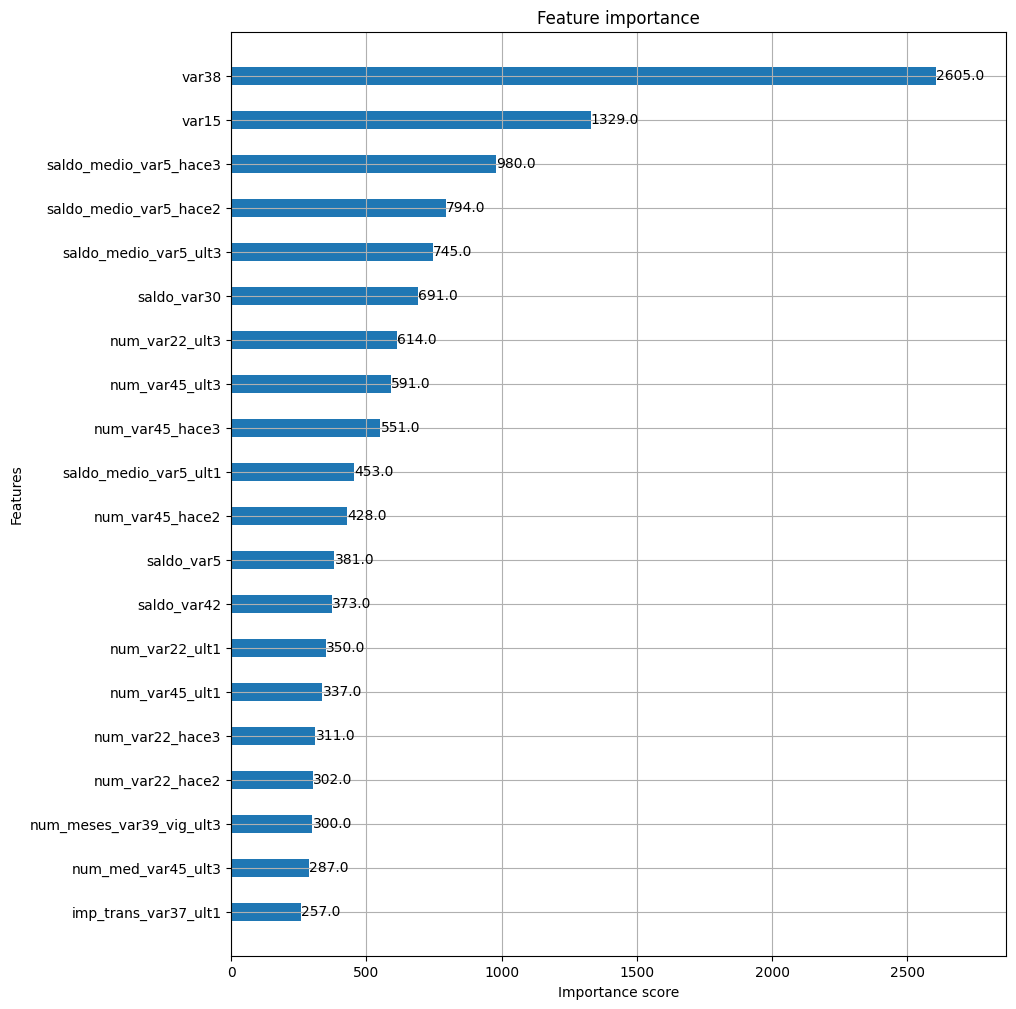

In [111]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax=plt.subplots(figsize=(10,12))
plot_importance(xgb_clf,ax=ax, max_num_features=20, height=0.4)

In [110]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score

lgbm_clf=LGBMClassifier(n_estimators=500, verbose=-1) # verbose를 -1로 설정하여 출력 메시지 제어

evals=[(X_test,y_test)]
lgbm_clf.fit(X_train,y_train,
            eval_metric='auc', # eval_metric은 fit에 직접 전달 가능
            eval_set=evals,
            callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=1)]) # early_stopping_rounds를 callbacks로 전달

lgbm_roc_score=roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1],average='macro')
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[1]	valid_0's auc: 0.817384	valid_0's binary_logloss: 0.165046
Training until validation scores don't improve for 100 rounds
[2]	valid_0's auc: 0.818903	valid_0's binary_logloss: 0.160006
[3]	valid_0's auc: 0.827707	valid_0's binary_logloss: 0.156323
[4]	valid_0's auc: 0.832155	valid_0's binary_logloss: 0.153463
[5]	valid_0's auc: 0.834677	valid_0's binary_logloss: 0.151256
[6]	valid_0's auc: 0.834093	valid_0's binary_logloss: 0.149427
[7]	valid_0's auc: 0.837046	valid_0's binary_logloss: 0.147961
[8]	valid_0's auc: 0.837838	valid_0's binary_logloss: 0.146591
[9]	valid_0's auc: 0.839435	valid_0's binary_logloss: 0.145455
[10]	valid_0's auc: 0.83973	valid_0's binary_logloss: 0.144486
[11]	valid_0's auc: 0.839799	valid_0's binary_logloss: 0.143769
[12]	valid_0's auc: 0.840034	valid_0's binary_logloss: 0.143146
[13]	valid_0's auc: 0.840271	valid_0's binary_logloss: 0.142533
[14]	valid_0's auc: 0.840342	valid_0's binary_logloss: 0.142036
[15]	valid_0's auc: 0.840928	valid_0's binary_loglos

In [113]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier, early_stopping

# 하이퍼 파라미터 테스트의 수행 속도를 향상시키기 위해 n_estimators를 200으로 감소
lgbm_clf = LGBMClassifier(n_estimators=200, verbose=-1)

params = {'num_leaves': [32, 64],
          'max_depth': [128, 160],
          'min_child_samples': [60, 100],
          'subsample': [0.8, 1]}

# cv는 3으로 지정
gridcv = GridSearchCV(lgbm_clf, param_grid=params, cv=3)
gridcv.fit(X_train, y_train, eval_metric="auc",
           eval_set=[(X_train, y_train), (X_test, y_test)],
           callbacks=[early_stopping(stopping_rounds=30)])

print('GridSearchCV 최적 파라미터:', gridcv.best_params_)
lgbm_roc_score = roc_auc_score(y_test, gridcv.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[7]	valid_0's auc: 0.847144	valid_0's binary_logloss: 0.13794	valid_1's auc: 0.837965	valid_1's binary_logloss: 0.147853
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[11]	valid_0's auc: 0.855647	valid_0's binary_logloss: 0.133227	valid_1's auc: 0.840035	valid_1's binary_logloss: 0.143552
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[28]	valid_0's auc: 0.87235	valid_0's binary_logloss: 0.12484	valid_1's auc: 0.840114	valid_1's binary_logloss: 0.139236
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[7]	valid_0's auc: 0.847144	valid_0's binary_logloss: 0.13794	valid_1's auc: 0.837965	valid_1's binary_logloss: 0.147853
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[11]	valid_0's auc: 0.855647	valid

In [115]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=32, subsample=0.8,
                          min_child_samples=100, max_depth=128, verbose=-1)

evals = [(X_test, y_test)]
lgbm_clf.fit(X_train, y_train,
             eval_metric='auc',
             eval_set=evals,
             callbacks=[early_stopping(stopping_rounds=100),  # 조기 중단
                        log_evaluation(period=1)])            # = verbose=True

lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[1]	valid_0's auc: 0.819488	valid_0's binary_logloss: 0.165016
Training until validation scores don't improve for 100 rounds
[2]	valid_0's auc: 0.822075	valid_0's binary_logloss: 0.159734
[3]	valid_0's auc: 0.829436	valid_0's binary_logloss: 0.156119
[4]	valid_0's auc: 0.836147	valid_0's binary_logloss: 0.153073
[5]	valid_0's auc: 0.839041	valid_0's binary_logloss: 0.150773
[6]	valid_0's auc: 0.839076	valid_0's binary_logloss: 0.148948
[7]	valid_0's auc: 0.839943	valid_0's binary_logloss: 0.147346
[8]	valid_0's auc: 0.84098	valid_0's binary_logloss: 0.146068
[9]	valid_0's auc: 0.840686	valid_0's binary_logloss: 0.14506
[10]	valid_0's auc: 0.841299	valid_0's binary_logloss: 0.144134
[11]	valid_0's auc: 0.841659	valid_0's binary_logloss: 0.14327
[12]	valid_0's auc: 0.841543	valid_0's binary_logloss: 0.14261
[13]	valid_0's auc: 0.841645	valid_0's binary_logloss: 0.14205
[14]	valid_0's auc: 0.841389	valid_0's binary_logloss: 0.14164
[15]	valid_0's auc: 0.84154	valid_0's binary_logloss: 0.1

In [116]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()

X_data = cancer_data.data
y_label = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.2, random_state=0)

In [117]:
# 개별 ML 모델 생성
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

# 스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델
# [수정] max_iter=1000 추가: 기본값(100)으로는 수렴 경고(ConvergenceWarning)가 뜰 수 있음
lr_final = LogisticRegression(C=10, max_iter=1000)

In [118]:
# 개별 모델들을 학습.
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [119]:
# 학습된 개별 모델들이 각자 반환하는 예측 데이터 세트를 생성하고 개별 모델의 정확도 측정.
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)
# [수정] gbm_pred = gbm_clf.predict(X_test) 삭제: gbm_clf를 만든 적이 없어서 NameError 발생 (책 오타)

print('KNN 정확도: {0:.4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정 트리 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))
print('에이다부스트 정확도: {0:.4f}'.format(accuracy_score(y_test, ada_pred)))

KNN 정확도: 0.9211
랜덤 포레스트 정확도: 0.9649
결정 트리 정확도: 0.9123
에이다부스트 정확도: 0.9737


In [120]:
pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred])
print(pred.shape)

# transpose를 이용해 행과 열의 위치 교환. 칼럼 레벨로 각 알고리즘의 예측 결과를 피처로 만듦.
pred = np.transpose(pred)
print(pred.shape)

(4, 114)
(114, 4)


In [121]:
lr_final.fit(pred, y_test)
final = lr_final.predict(pred)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(accuracy_score(y_test, final)))

최종 메타 모델의 예측 정확도: 0.9737


In [122]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수.
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    # 지정된 n_folds값으로 KFold 생성.
    # [수정] random_state=0 삭제: shuffle=False일 때 random_state를 넣으면 최신 사이킷런에서 ValueError 발생
    kf = KFold(n_splits=n_folds, shuffle=False)
    # 추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred = np.zeros((X_train_n.shape[0], 1))
    test_pred = np.zeros((X_test_n.shape[0], n_folds))
    print(model.__class__.__name__, ' model 시작 ')

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        # 입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트 추출
        print('\t 폴드 세트: ', folder_counter, ' 시작 ')
        X_tr = X_train_n[train_index]
        y_tr = y_train_n[train_index]
        X_te = X_train_n[valid_index]

        # 폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행.
        model.fit(X_tr, y_tr)
        # 폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장.
        train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1, 1)
        # 입력된 원본 테스트 데이터를 폴드 세트내 학습된 기반 모델에서 예측 후 데이터 저장.
        test_pred[:, folder_counter] = model.predict(X_test_n)

    # 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)

    # train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터
    return train_fold_pred, test_pred_mean

In [123]:
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

KNeighborsClassifier  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
	 폴드 세트:  5  시작 
	 폴드 세트:  6  시작 
RandomForestClassifier  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
	 폴드 세트:  5  시작 
	 폴드 세트:  6  시작 
DecisionTreeClassifier  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
	 폴드 세트:  5  시작 
	 폴드 세트:  6  시작 
AdaBoostClassifier  model 시작 
	 폴드 세트:  0  시작 
	 폴드 세트:  1  시작 
	 폴드 세트:  2  시작 
	 폴드 세트:  3  시작 
	 폴드 세트:  4  시작 
	 폴드 세트:  5  시작 
	 폴드 세트:  6  시작 


In [124]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
print('원본 학습 피처 데이터 Shape:', X_train.shape, '원본 테스트 피처 Shape:', X_test.shape)
print('스태킹 학습 피처 데이터 Shape:', Stack_final_X_train.shape,
      '스태킹 테스트 피처 데이터 Shape:', Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape: (455, 30) 원본 테스트 피처 Shape: (114, 30)
스태킹 학습 피처 데이터 Shape: (455, 4) 스태킹 테스트 피처 데이터 Shape: (114, 4)


In [125]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
print('원본 학습 피처 데이터 Shape:', X_train.shape, '원본 테스트 피처 Shape:', X_test.shape)
print('스태킹 학습 피처 데이터 Shape:', Stack_final_X_train.shape,
      '스태킹 테스트 피처 데이터 Shape:', Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape: (455, 30) 원본 테스트 피처 Shape: (114, 30)
스태킹 학습 피처 데이터 Shape: (455, 4) 스태킹 테스트 피처 데이터 Shape: (114, 4)
